# **Stroke Prediction Marketing Analysis**

#### By: Sophie Gilsten, Brittany	Goldberg, Allison Olazabal, Juliana Robilotti

## **Introduction:**

### **Can we predict a stroke based on a variety of health and life factors?**
We are a team of data analysts at Pfizer whose next project is to investigate health trends and risks factors associated with strokes. Our ultimate goal is to **guide a marketing strategy for a new medication** targeted at
individuals who are at a higher risk of experiencing a stroke. Our research focuses on **uncovering which medical conditions and lifestyle choices most significantly contribute to the likelihood of a stroke.** By identifying patterns in stroke prevalence, we aim to provide Pfizer with insights that will help refine their target audience and **improve preventative strategies.**


In order to conduct this analysis, we are using a dataset that provides a comprehensive description of each patient. It includes demographic data such as **age**, **gender**, and **marital status**; health-related factors like history of **hypertension**, **heart disease**, and **BMI**; lifestyle habits such as **smoking status**; and socioeconomic details including **residence type** and **work type**. This dataset enables us to explore the relationships between these variables and the occurrence of stroke.


### **The Dataset:**

The origin of the dataset is from Kaggle under an owner named **“fedesoriano”**. The kaggle user obtained the data from the **World Health Organization.** You can find the link [here](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data). As we mentioned before there are 10 columns of stroke predictors, one column indicating **whether or not the patient had a stroke** and 1 column for the patients **unique id number.** Out of the predictor columns, there are 7 categorical variables: **gender, hypertension, heart_disease, ever_married, work_type, Residence_type, smoking_status** and 3 numerical: **age, avg_glucose_level, bmi.**


Based on the National Institue of Health, the highest risk factors that may contribute to stroke are **high blood pressure, obesity, physical inactivity, poor diet, and smoking**. We will use our data to find out if these relationships are true and how we can use this information to better market preventative medication.


---
**Sources:**

“Stroke — Causes and Risk Factors .” National Heart Lung and Blood Institute, U.S. Department of Health and Human Services, 26 May 2023, www.nhlbi.nih.gov/health/stroke/causes.


### **Loading and cleaning:**

In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.tree import *
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#uploading from github
!git clone https://github.com/sgilsten/stroke_data

Cloning into 'stroke_data'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 66.33 KiB | 11.05 MiB/s, done.


In [ ]:
#loading dataset
dataframe = '/content/stroke_data/stroke_data.csv'
stroke = pd.read_csv(dataframe)
stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#checking for null values
stroke.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
#replace null values with median value instead as data is skewed
bmi_median = stroke['bmi'].median()
stroke['bmi'] = stroke['bmi'].fillna(bmi_median)

In [ ]:
#cleaning up by dropping id column
stroke = stroke.drop("id", axis=1)

In [ ]:
#visualizing our new dataset
stroke.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## **Research Questions and Analysis:**

### **1) How does age and gender influence the likelihood of a stroke?**

In [ ]:
#First, we are finding the range of ages within the dataset
stroke["age"].min()

0.08

In [ ]:
stroke["age"].max()

82.0

In [ ]:
#Next, we are dividing the  numerical category of age into 6 sub categories ot age groups to better analyze patterns by age
bins=[0, 12, 18, 30, 45, 60, 82]
labels=["Children(0-12)", "Teens(13-18)", "Young Adults(19-30)", "Middle-Aged Adults(31-45)", "Older Adults(46-60)", "Seniors(61-82)"]
stroke["age_groups"] = pd.cut(stroke["age"], bins=bins, labels=labels, right=True)

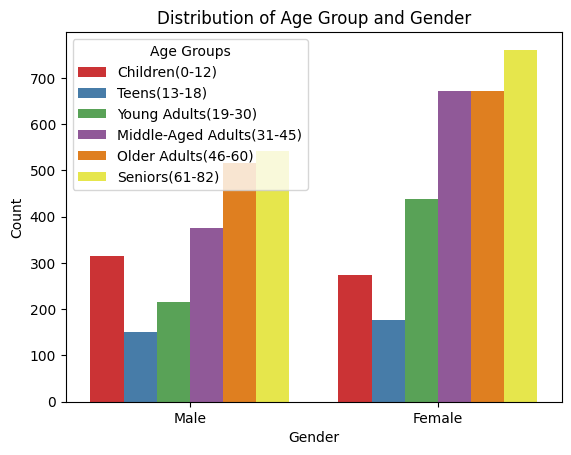

In [ ]:
#Bar graph that displays the total age group and gender distribution of the data
sns.countplot(stroke, x="gender", hue="age_groups", palette="Set1", order=["Male", "Female"])
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of Age Group and Gender")
plt.legend(title='Age Groups')
plt.show()

To **contextualize** the age distribution specific to this dataset, this visualization demonstrates how the age groups of *Children* and *Teens* are closer together in range for both men and women. However, from the age groups of *Young Adults* to *Seniors*, ranging from 19+, there are significantly more women within those age groups in comparison to men. This visualization gives our team context towards the ages of men and women that are included within this dataset.

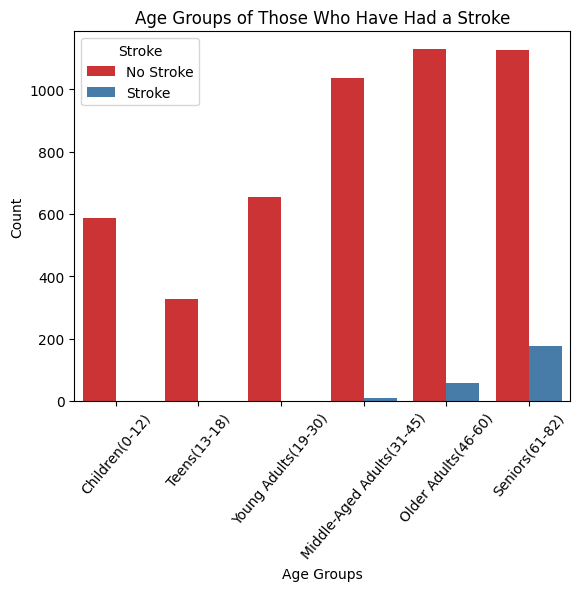

In [ ]:
#Bar graph that displays the age groups that have and have not had a stroke
sns.countplot(stroke, x="age_groups", hue="stroke", palette="Set1")
plt.xlabel("Age Groups")
plt.ylabel("Count")
plt.title("Age Groups of Those Who Have Had a Stroke")
plt.xticks(rotation=50)
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

The bar graph supports of the general trend that the likelihood of a stroke increases with age as the *Stroke* category exponentially increases from the *Middle-Aged Adults* group into the *Seniors* group.

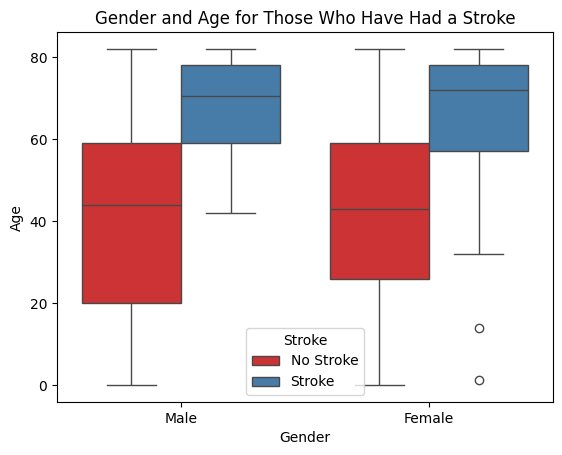

In [ ]:
#Box plot of the age and gender distribution for those who have and have not had a stroke
ax=sns.boxplot(stroke, x="gender", y="age", hue="stroke", palette="Set1", hue_order=[0,1], order=["Male", "Female"])
plt.xlabel("Gender")
plt.ylabel("Age")
plt.title("Gender and Age for Those Who Have Had a Stroke")
handles, labels=ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

For men, the age range for **not** having had a stroke is from around 20 to late 50s, while the age range for women is smaller from mid 20s to late 50s. This range falls under these groups: *Young Adults*, *Middle-Ages Adults*, and *Older Adults*. The age range for men who **have had** a stroke is from 60 to late 70s, while the age range for women who have had a stroke is a bit bigger with some overlap from late 50s to late 70s. The **median** age for men who have had a stroke is around 70, while for women their median age for having had a stroke is slightly higher. This model supports the claim that the likelihood of a stroke increases with age, especially under the *Seniors* age group. Since the median stroke age is around the same, gender doesn't have as a significant influence or relationship to having a stroke.

### **2) How does employment and area of residency impact one’s likelihood of a stroke?**

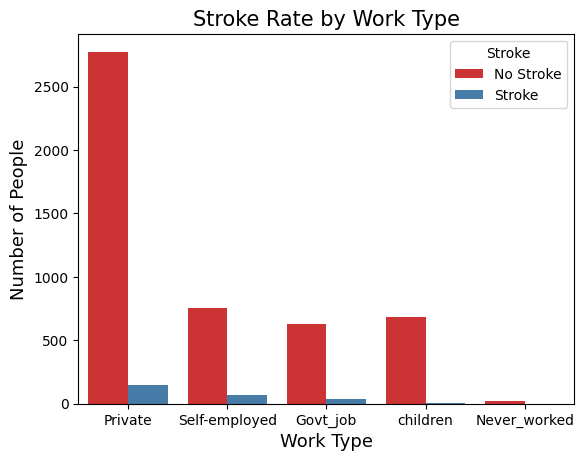

In [ ]:
#Bar graph comparing work type and stroke likelihood
sns.countplot(stroke, x='work_type', hue='stroke', palette='Set1')
plt.title('Stroke Rate by Work Type', fontsize=15)
plt.xlabel('Work Type', fontsize=13)
plt.ylabel('Number of People', fontsize=13)
plt.xticks()
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

This bar graph illustrates how different types of employment relate to stroke risk. Red bars represent individuals who **did not** experience a stroke, while blue bars represent those who **did**. The data shows that people who are **self-employed** or work for **private companies** are more likely to have a stroke, which may be linked to the **higher stress** levels often associated with these roles. This suggests that someone's workplace could be an **important** factor to consider when designing a marketing strategy for the medication.


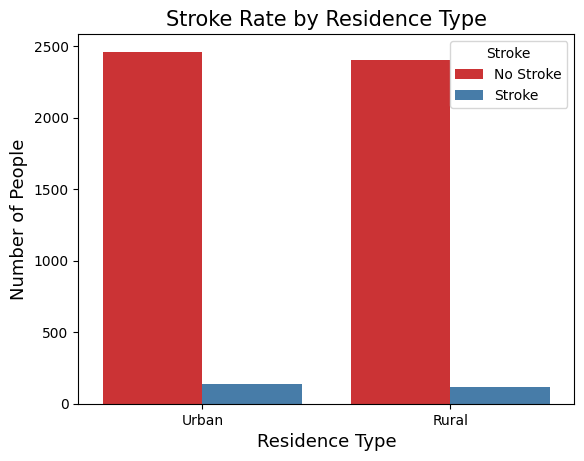

In [ ]:
#Bar graph comparing residence type and stroke likelihood
sns.countplot(data=stroke, x='Residence_type', hue='stroke', palette='Set1')
plt.title('Stroke Rate by Residence Type', fontsize=15)
plt.xlabel('Residence Type', fontsize=13)
plt.ylabel('Number of People', fontsize=13)
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

This bar graph illustrates how different types of residence relate to stroke risk. Red bars represent individuals who **did not** experience a stroke, while blue bars represent those who **did**. The data shows that people who live in **urban areas** are marginally more likely to have a stroke, which may be linked to the **higher stress** levels often associated with these areas or **increased air pollution**. Do to the minute difference, it seems that someone's residence is **not** an especially important factor to consider when designing a marketing strategy for the medication.

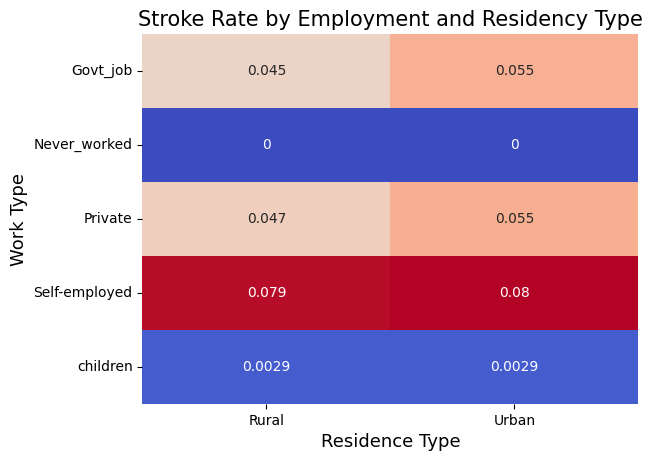

In [ ]:
#Heat map comparing residence and employment type vs stroke likelihood
stroke1 = stroke.groupby(['work_type', 'Residence_type'])['stroke'].mean().unstack()
sns.heatmap(stroke1, annot=True, cmap="coolwarm", cbar=False)
plt.title('Stroke Rate by Employment and Residency Type', fontsize=15)
plt.ylabel('Work Type', fontsize=13)
plt.xlabel('Residence Type', fontsize=13)
plt.show()

Strokes are often analyzed through a medical lens, but I wanted to explore whether **socioeconomic factors** also play a role. To make this easier to visualize, I first broke down each factor **individually** to understand its **specific impact**. The final graph, a heatmap, shows how **residence type** and **employment status** relate to **stroke likelihood**, based on the dataset. The numbers represent the **percentage** of people in each category who experienced a stroke. For example, 8% of self-employed individuals living in urban areas had a stroke, while none of the individuals who never worked experienced one.

This insight can support our campaign in a few ways. Traditionally, urban populations receive more marketing attention due to higher density and spending power. However, since the data shows only a small difference between urban and rural stroke rates, we have an opportunity to **expand our campaign outreach**. Additionally, recognizing which types of jobs are more closely linked to stroke risk can help us better **target the medication** to those who may benefit most. When combined with later findings, this analysis can help define a **detailed profile** of our **ideal client.**

### **3) Based on gender, smoking, and marriage status, can we predict whether a person will develop a stroke?**

In [ ]:
y = (stroke['stroke'] == 1).astype("string")
y.value_counts()
#This code sets the y-variable as stroke, with 1 meaning that the person had a stroke and 0 meaning the person did not have a stroke. The y-variable is what is being predicted by the decision tree

,count
stroke,
False,4861
True,249


In [ ]:
X = stroke[['gender', 'ever_married', 'smoking_status']]
X = pd.get_dummies(X,drop_first=True).astype("float32")
#This code sets the x-variable as stroke. The x-variable is what is being used by the algorithm to predict whether a person has a stroke or not

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314159)
#This code splits the data into training groups and testing groups, with 75% of the data being used fro training and 25% of the data being used to test the algorithm

In [ ]:
model = DecisionTreeClassifier().fit(X_train, y_train)

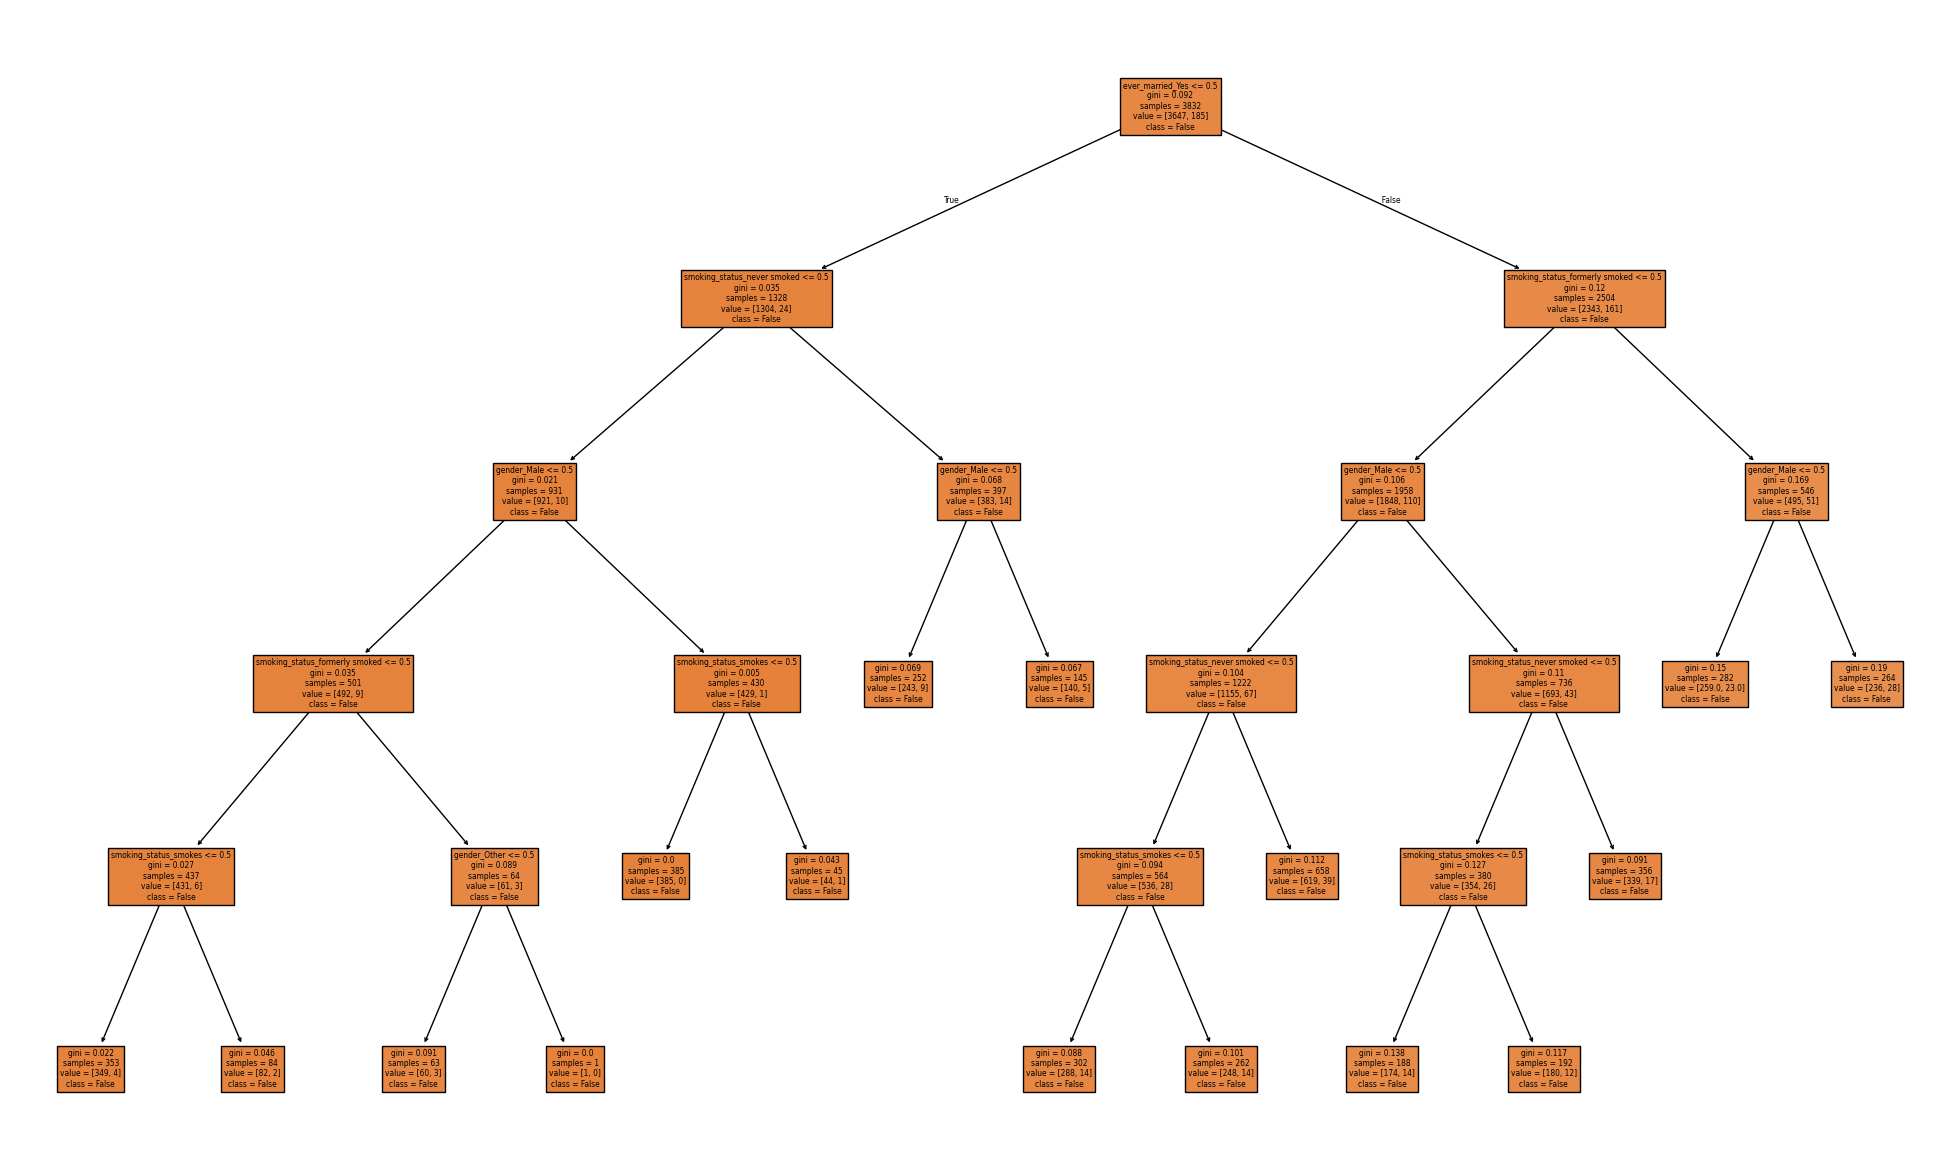

In [ ]:
fig = plt.figure(figsize=(25,15))
plot_tree(model,
          class_names = y.sort_values().unique(),
          feature_names=X.columns,
          filled=True, impurity=True);

In [ ]:
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(yhat_train, y_train):.2f}")
print(f"Test Accuracy:  {accuracy_score(yhat_test, y_test):.2f}")
print(f"Null Accuracy:  {y_test.value_counts(normalize=True).iloc[0]:.2f}")
#This code allows us to evalutate the algorithm by checking the train, test, and null accuracies

Train Accuracy: 0.95
Test Accuracy:  0.95
Null Accuracy:  0.95


This model shows that marriage status is the highest priority question out of the three. Despite marriage status being the highest priority out of marriage status, smoking status, and gender, in general **these three characteristics do not have a stong impact on the likelihood of developing a stroke**. We figured this out because the test accuracy from the decision tree is the same as the null accuracy, meaning **the model is not better than a random model**. Also, based on the random forest shown in response to question 4, marriage status, smoking status, and gender do not have a strong impact on a person's likelihood of developing a stroke when compared to other characteristics such as glucose level, age, and bmi.

### **4) Which factors most heavily contribute to the likelihood of a stroke?**

To answer this research question, we need to isolate our independent and dependent variables. The dependent variable is if a stroke occurs or not in a patient, while the independent variables are factors that may contribut to the likelihood of a stroke.

In [ ]:
# assign variables from the dataframe to X
X = stroke[['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status']]

# assign stroke indicator variable to y
y = stroke["stroke"]

# change the categorical variables to numeric values
X = pd.get_dummies(X,drop_first=True)
feature_names = X.columns.tolist()

In [ ]:
# Next the data has to be split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=314159)

In [ ]:
# The selected variables are trained and fit to a model
model = RandomForestClassifier().fit(X_train, y_train)

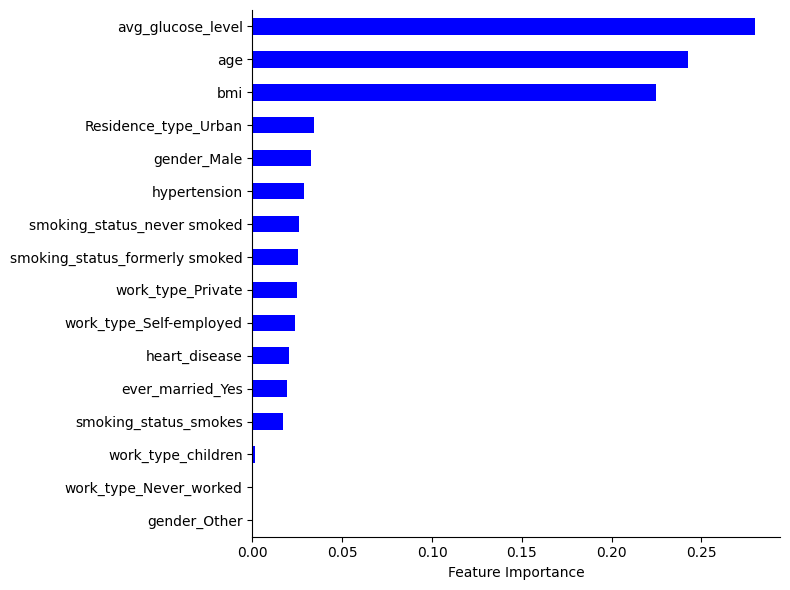

In [ ]:
# plot the model into a bar graph, best predictors will be at the top of the graph
forest_importances = pd.Series(model.feature_importances_,index=feature_names)
forest_importances.sort_values(inplace=True, ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
forest_importances.plot.barh(ax=ax, color='blue')
ax.set_xlabel("Feature Importance")

ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()

In [ ]:
yhat_train = model.predict(X_train)
yhat_test = model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(yhat_train, y_train):.2f}")
print(f"Test Accuracy:  {accuracy_score(yhat_test, y_test):.2f}")
print(f"Null Accuracy:  {y_test.value_counts(normalize=True).iloc[0]:.2f}")

Train Accuracy: 1.00
Test Accuracy:  0.95
Null Accuracy:  0.95


This is a model that visualizes all the variables and sorts them in terms of which are the best predictors of a stroke. The variables that are the **best predictors are blood glucose levels, bmi, and age**. Factors refering to physical health and conditions are better to use when predicting if a stroke will occur. Though the factors appear to be significant, **the test accuracy from the random forest is the same as the null accuracy**. The physical factors would be used by Pfizer to market the new medication to older demographics affected by glucose levels and bmi.

## **Conclusion:**

After contextualizing the age distribution and gender distribution of the dataset, those of an **older age are more susceptible to having a stroke**, with a **median age** in the **early 70s**. Based on the socioeconomic factors of residence and employment type, we found that individuals who work for **private companies** or are **self-employed** are **significantly more likely** to experience a stroke compared to those in other job categories. Interestingly, there was **virtually no difference** in stroke likelihood between **urban** and **rural** residents; people in both settings appear equally at risk. When discussing other social determinants of developing a stroke based on gender, marriage status, and smoking status, **marriage status was the highest priority**. Looking at all variables within the dataset, the factors that affected the likelihood of a stroke were factors pertaining to physical health. These included **blood glucose levels and BMI**. Social health factors did not appear to have a meaningful contribution to whether or not a stroke would occur in an individual.
For marketing a new stroke medication, we recommend that the campaign be targeted **towards unmarried adults aged 46 and up who struggle with their blood glucose levels and BMI.** We would also recommend that the marketing campaign **be extended into rural areas**, which are often underserved, and to specifically target individuals who are s**elf-employed or employed by private companies**.
 We believe our analysis was **somewhat effective**; this is because the test accuracy from the models was the **same as the null accuracy**, meaning the model is **not better** than a random model. External research suggests that medical factors are the strongest predictors of stroke. To improve the models, we would suggest including **more medical and numeric data** as it would have made the campaign stronger.
